In [1]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from sklearn.feature_extraction.text import TfidfVectorizer #
import torchvision.transforms as transforms #
import random
import numpy as np
import matplotlib.pyplot as plt
import timm
from collections import Counter #

/home/phananh/miniconda3/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
class VQADataset(Dataset):
    def __init__(self, json_path, data_dir, transform=None, vocab=None):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.data_dir = data_dir
        self.transform = transform
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        img_path = os.path.join(self.data_dir, item['image_path'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        question = item['question']

        answer = item['answer']
        answer_idx = self.vocab.get(answer, -1)
        answers = item.get('answers', [answer])

        return {
            'image': image,
            'question': question,
            'answer': answer_idx,
            'raw_answer': answer,
            'answers': answers
            }

In [4]:
def get_transforms(img_size=1024):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

In [5]:
def build_answer_vocab(train_data, val_data, max_answers=10000):
    all_answers = []
    for item in train_data:
        all_answers.extend(item.get("answers", [item["answer"]]))

    for item in val_data:
        all_answers.extend(item.get("answers", [item["answer"]]))

    answer_counts = Counter(all_answers)
    unique_answers = list(answer_counts.keys())

    if len(unique_answers) > max_answers:
        unique_answers = [ans for ans,_ in answer_counts.most_common(max_answers)]

    vocab = {ans: idx for idx, ans in enumerate(sorted(unique_answers))}
    
    print(f"Build vocab: {len(vocab)} answers")

    return vocab


In [6]:
data_dir = './data/vqav2'
batch_size = 32
img_size = 224
tfidf_dim = 1000

In [7]:
train_transform, val_transform = get_transforms(img_size=img_size)

with open(os.path.join(data_dir, 'train.json'), 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(os.path.join(data_dir, 'val.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)

vocab = build_answer_vocab(train_data, val_data)
num_classes = len(vocab)
idx_to_ans = {idx: ans for ans, idx in vocab.items()}

print(f'Number of classes: {num_classes}')
print(f'Number of classes: {len(idx_to_ans)}')

Build vocab: 4611 answers
Number of classes: 4611
Number of classes: 4611


In [8]:
train_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'train.json'),
    data_dir=data_dir,
    transform=train_transform,
    vocab=vocab
)

val_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'val.json'),
    data_dir=data_dir,
    transform=val_transform,
    vocab=vocab
)

test_dataset = VQADataset(
    json_path=os.path.join(data_dir, 'test.json'),
    data_dir=data_dir,
    transform=val_transform,
    vocab=vocab
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [9]:
all_questions = []
for batch in train_loader:
    all_questions.extend(batch['question'])

tfidf_vectorizer = TfidfVectorizer(max_features=tfidf_dim)
tfidf_vectorizer.fit(all_questions)

print(f"TFIDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

TFIDF vocabulary size: 1000


# 3. Xây dựng Mô hình

In [10]:
class MLPBaseline(nn.Module):
    def __init__(self, num_classes, img_size, tfidf_dim, tfidf_vectorizer, hidden_dim=512):
        super().__init__()
        self.img_size = img_size
        self.tfidf_dim = tfidf_dim
        self.img_flatten_dim = 3 * img_size * img_size
        self.tfidf_vectorizer = tfidf_vectorizer

        fusion_dim = self.img_flatten_dim + tfidf_dim
        self.bottleneck = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def encode_questions(self, questions):
        tfidf_features = self.tfidf_vectorizer.transform(questions).toarray()
        return torch.FloatTensor(tfidf_features)

    def forward(self, images, questions):
        batch_size = images.size(0)

        img_features = images.view(batch_size, -1)
        text_features = self.encode_questions(questions).to(images.device)

        combined = torch.cat([img_features, text_features], dim=1)
        fused_features = self.bottleneck(combined)
        output = self.classifier(fused_features)

        return output

In [11]:
def compute_vqa_accuracy(prediction, ground_truth_answers):
    if not ground_truth_answers:
        return 0.0
    
    count = 0
    pred = prediction.lower().strip()
    
    for ans in ground_truth_answers:
        if ans.lower().strip() == pred:
            count += 1
    
    return min(1.0, count/3.0)

In [12]:
def levenshtein_distance(s1, s2):
    if len(s1) > len(s2):
        s1, s2 = s2, s1

    distances = range(len(s1) + 1)
    for i2, c2 in enumerate(s2):
        distances_ = [i2+1]
        for i1, c1 in enumerate(s1):
            if c1 == c2:
                distances_.append(distances[i1])
            else:
                distances_.append(1 + min((distances[i1], distances[i1 + 1], distances_[-1])))
        distances = distances_
    return distances[-1]

In [13]:
def compute_anls(target, prediction):
    target = target.lower().strip()
    prediction = prediction.lower().strip()

    if not target or not prediction:
        return 0.0 if target != prediction else 1.0

    dist = levenshtein_distance(target, prediction)
    max_len = max(len(target), len(prediction))

    score = 1.0 - float(dist) / float(max_len)
    return score if score >= 0.5 else 0.0

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device, idx_to_ans):
    model.train()
    total_loss = 0
    sum_vqa_acc = 0
    total_samples = 0

    for batch in dataloader:
        images = batch['image'].to(device)
        questions = batch['question']
        answers = batch['answer'].to(device)
        raw_answers = batch['raw_answer']
        gt_answers_list = batch.get('answers', [[ans] for ans in raw_answers])

        if isinstance(gt_answers_list, list) and len(gt_answers_list) > 0 and isinstance(gt_answers_list[0], (list, tuple)):
            gt_answers_list = list(zip(*gt_answers_list))

        valid_mask = answers != -1
        if not valid_mask.any():
            continue

        optimizer.zero_grad()
        outputs = model(images, questions)

        v_outputs = outputs[valid_mask]
        v_answers = answers[valid_mask]
        loss = criterion(v_outputs, v_answers)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * v_answers.size(0)
        batch_size = images.size(0)
        total_samples += batch_size

        _, predicted = outputs.max(1)
        for i in range(batch_size):
            pred_id = predicted[i].item()
            pred_text = idx_to_ans.get(pred_id, "")
            gt_list = gt_answers_list[i]
            sum_vqa_acc += compute_vqa_accuracy(pred_text, gt_list)
    
    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    vqa_acc = 100. * sum_vqa_acc / total_samples if total_samples > 0 else 0

    return avg_loss, vqa_acc

In [15]:
def evaluate(model, dataloader, criterion,  device, idx_to_ans):
    model.eval()

    total_loss = 0

    correct_top1 = 0
    correct_top5 = 0
    total_valid_vocab = 0

    sum_vqa_acc = 0
    sum_vqa_top5 = 0

    sum_anls = 0
    total_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            questions = batch['question']
            answers = batch['answer'].to(device)
            raw_answers = batch['raw_answer']
            gt_answers_list = batch.get('answers', [[ans] for ans in raw_answers])

            if isinstance(gt_answers_list, list) and len(gt_answers_list) > 0 and isinstance(gt_answers_list[0], (list, tuple)):
                gt_answers_list = list(zip(*gt_answers_list))

            batch_size = images.size(0)
            total_samples += batch_size

            valid_mask = answers != -1
            if not valid_mask.any():
                continue

            outputs = model(images, questions)
            v_outputs = outputs[valid_mask]
            v_answers = answers[valid_mask]
            loss = criterion(v_outputs, v_answers)
            total_loss += loss.item() * v_answers.size(0)

            _, predicted = v_outputs.max(1)
            correct_top1 += predicted.eq(v_answers).sum().item()

            _, top5_preds = v_outputs.topk(min(5, v_outputs.size(1)), 1)
            correct_top5 += (top5_preds == v_answers.view(-1, 1)).sum().item()

            total_valid_vocab += valid_mask.sum().item()

            _, top5_all = outputs.topk(min(5, outputs.size(1)), 1)

            for i in range(batch_size):
                pred_id = top5_all[i, 0].item()
                pred_text_top1 = idx_to_ans.get(pred_id, "")
                gt_list = gt_answers_list[i]

                # Top-1 VQA
                sum_vqa_acc += compute_vqa_accuracy(pred_text_top1, gt_list)

                # Top-5 VQA: max VQA score among top 5
                vqa_scores_top5 = [compute_vqa_accuracy(idx_to_ans.get(top5_all[i, j].item(), ""), gt_list) for j in range(top5_all.size(1))]
                sum_vqa_top5 += max(vqa_scores_top5)

                # ANLS (Top-1)
                sum_anls += compute_anls(raw_answers[i], pred_text_top1)

    avg_loss = total_loss / total_valid_vocab if total_samples > 0 else 0
    acc_top1 = 100. * correct_top1 / total_valid_vocab if total_valid_vocab > 0 else 0
    acc_top5 = 100. * correct_top5 / total_valid_vocab if total_valid_vocab > 0 else 0

    vqa_acc = 100. * sum_vqa_acc / total_samples if total_samples > 0 else 0
    vqa_top5 = 100. * sum_vqa_top5 / total_samples if total_samples > 0 else 0
    avg_anls = sum_anls / total_samples if total_samples > 0 else 0


    return avg_loss, acc_top1, acc_top5, vqa_acc, vqa_top5, avg_anls

In [16]:
hidden_dim = 512
model = MLPBaseline(num_classes=num_classes, img_size=img_size, tfidf_dim=tfidf_dim, tfidf_vectorizer=tfidf_vectorizer, hidden_dim=hidden_dim).to(device)

In [17]:
num_epochs = 10
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [18]:
history = {"train_loss": [], 
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
            }

In [ ]:
def plot_training_history(history, save_path='training_history.pdf', model_name='Model'):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax1.plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{model_name} - Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Plot Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
    ax2.plot(epochs, history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title(f'{model_name} - Training & Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_final_results(train_acc, val_acc, test_acc, save_path='final_results.pdf', model_name='Model'):
    splits = ['Train', 'Validation', 'Test']
    accuracies = [train_acc, val_acc, test_acc]
    colors = ['steelblue', 'coral', 'mediumseagreen']

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(splits, accuracies, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.annotate(f'{acc:.2f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=12, fontweight='bold')

    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Final Results', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(accuracies) * 1.15)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
best_vqa_acc = 0
best_epoch = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, idx_to_ans)

    val_metrics = evaluate(model, val_loader, criterion, device, idx_to_ans)
    val_loss, val_acc, val_top5, val_vqa, val_vqa_top5, val_anls = val_metrics

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_vqa)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val VQA Acc: {val_vqa:.2f}%, Val VQA Top5: {val_vqa_top5:.2f}%, Val ANLS: {val_anls:.4f}")

    if val_vqa > best_vqa_acc:
        best_vqa_acc = val_vqa
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vqa_acc': val_vqa,
            'vqa_top5': val_vqa_top5,
            'anls': val_anls,
        }, 'mlp_best.pth')
        print(f"Saved best model with VQA Acc: {val_vqa:.2f}%")

Epoch 1/10
Train Loss: 13.1144, Train Acc: 2.17%
Val VQA Acc: 1.50%, Val VQA Top5: 9.57%, Val ANLS: 0.0160
Saved best model with VQA Acc: 1.50%


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, device, idx_to_ans)
test_loss, test_acc, test_top5, test_vqa, test_vqa_top5, test_anls = test_metrics
print(f"Test VQA Acc: {test_vqa:.2f}%, Test VQA Top5: {test_vqa_top5:.2f}%, Test ANLS: {test_anls:.4f}")

Test VQA Acc: 1.27%, Test VQA Top5: 8.33%, Test ANLS: 0.0060


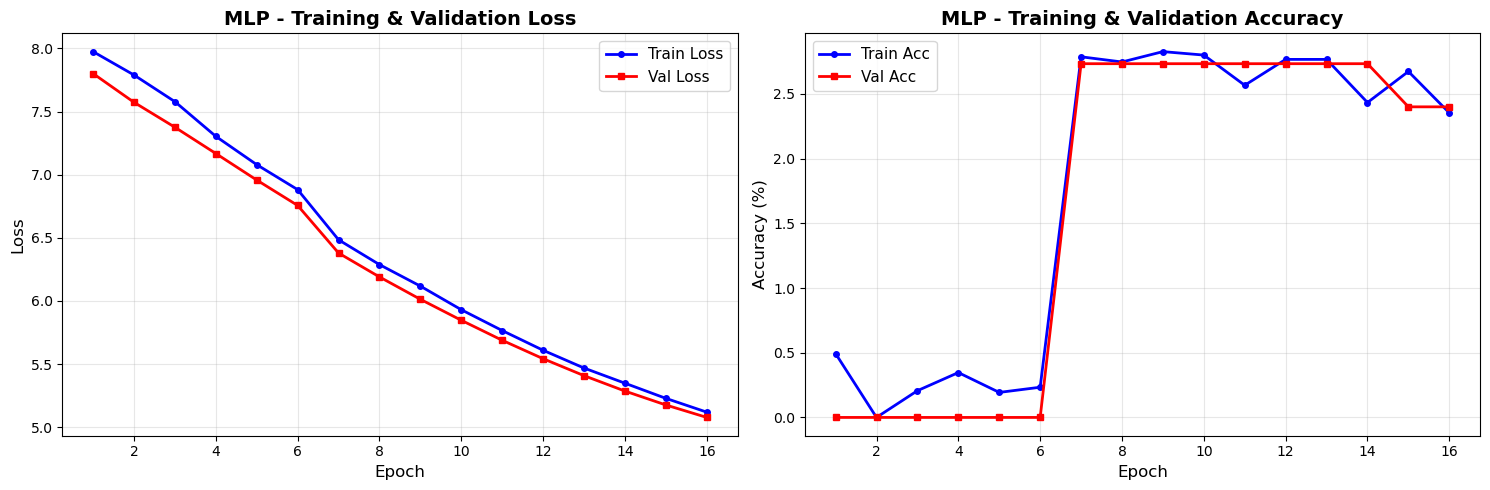

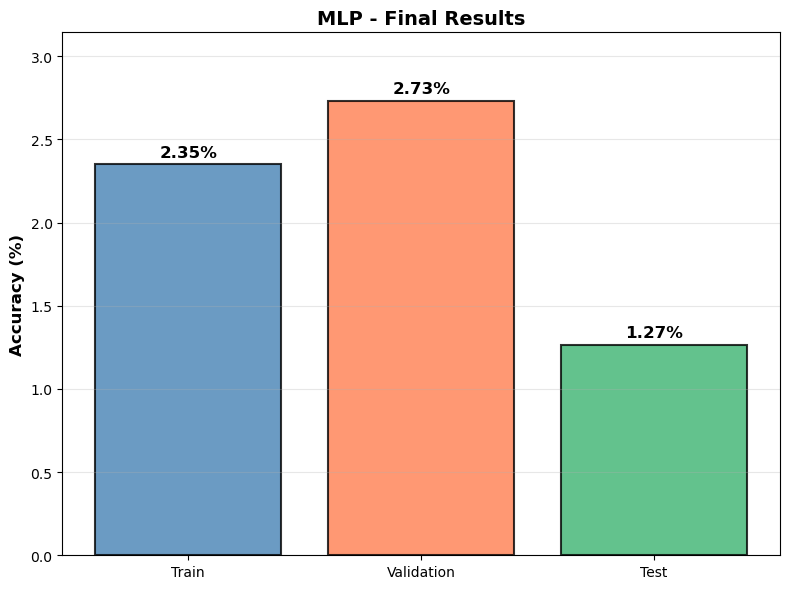

In [ ]:
plot_training_history(history, save_path='cnn_lstm_history.pdf', model_name='MLP')
plot_final_results(history['train_acc'][-1], best_vqa_acc, test_vqa,
                  save_path='MLP_results.pdf', model_name='MLP')